# Notebook 7 — Explainability with SHAP
This notebook explains model decisions for the XGBoost classifier using SHAP values. In industrial ML, explainability is essential because maintenance teams need to trust and operationalize model alerts, not just receive a probability score.

## Imports and SHAP module functions
We call reusable functions from `src.evaluation.shap_xgboost` to keep this notebook aligned with the script pipeline.

The following cell loads model/features and computes SHAP values on a sampled test subset.

In [1]:
%matplotlib inline
from pathlib import Path
import sys

import joblib
import numpy as np
import pandas as pd
import shap
from IPython.display import Image, display

cwd = Path.cwd()
project_root = cwd if (cwd / "src").exists() else cwd.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.evaluation.shap_xgboost import (
    MODEL_PATH,
    _load_features,
    _resolve_shap_values,
    _save_summary_plots,
    _save_waterfall_plot,
 )

X = _load_features()
model = joblib.load(MODEL_PATH)
X_sample = X.sample(n=min(2000, len(X)), random_state=42)

explainer = shap.TreeExplainer(model)
shap_values, base_value = _resolve_shap_values(explainer, X_sample)
summary_path, bar_path = _save_summary_plots(shap_values, X_sample, max_display=20)
waterfall_path = _save_waterfall_plot(shap_values, base_value, X_sample, row_index=0, max_display=20)

print("Model:", MODEL_PATH)
print("Sample shape:", X_sample.shape)

Model: C:\Users\avarg\OneDrive\Documentos\proyect-PMA\predictive-maintenance-automotive\saved_models\xgboost.pkl
Sample shape: (2000, 95)


## Display generated SHAP images
We show the three saved explainability artifacts from `assets/images/`.

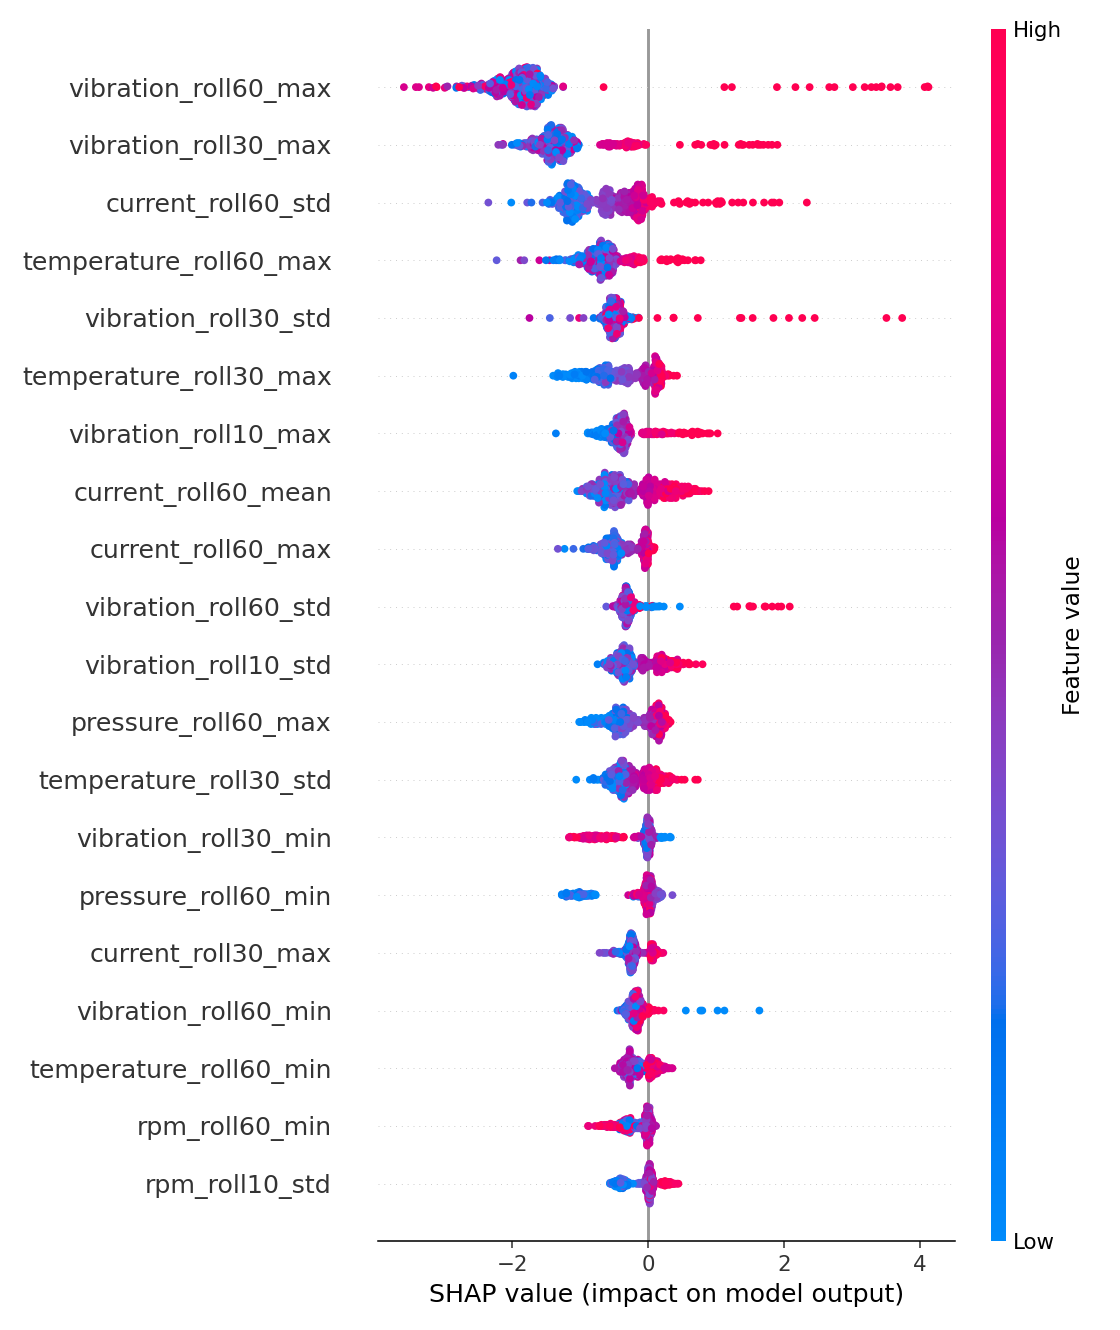

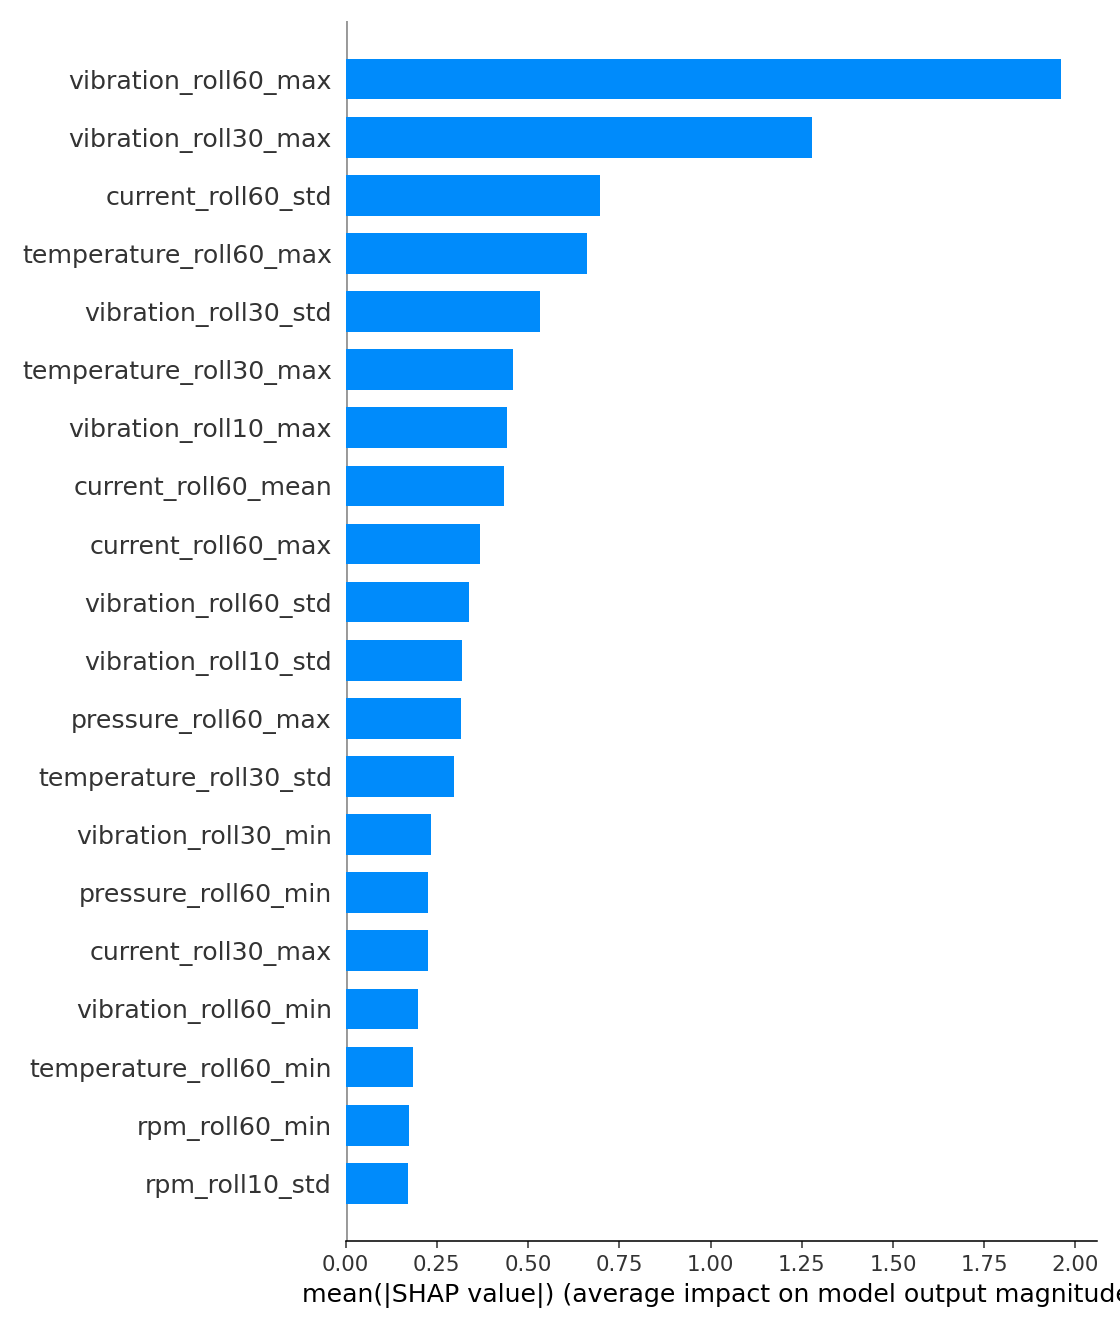

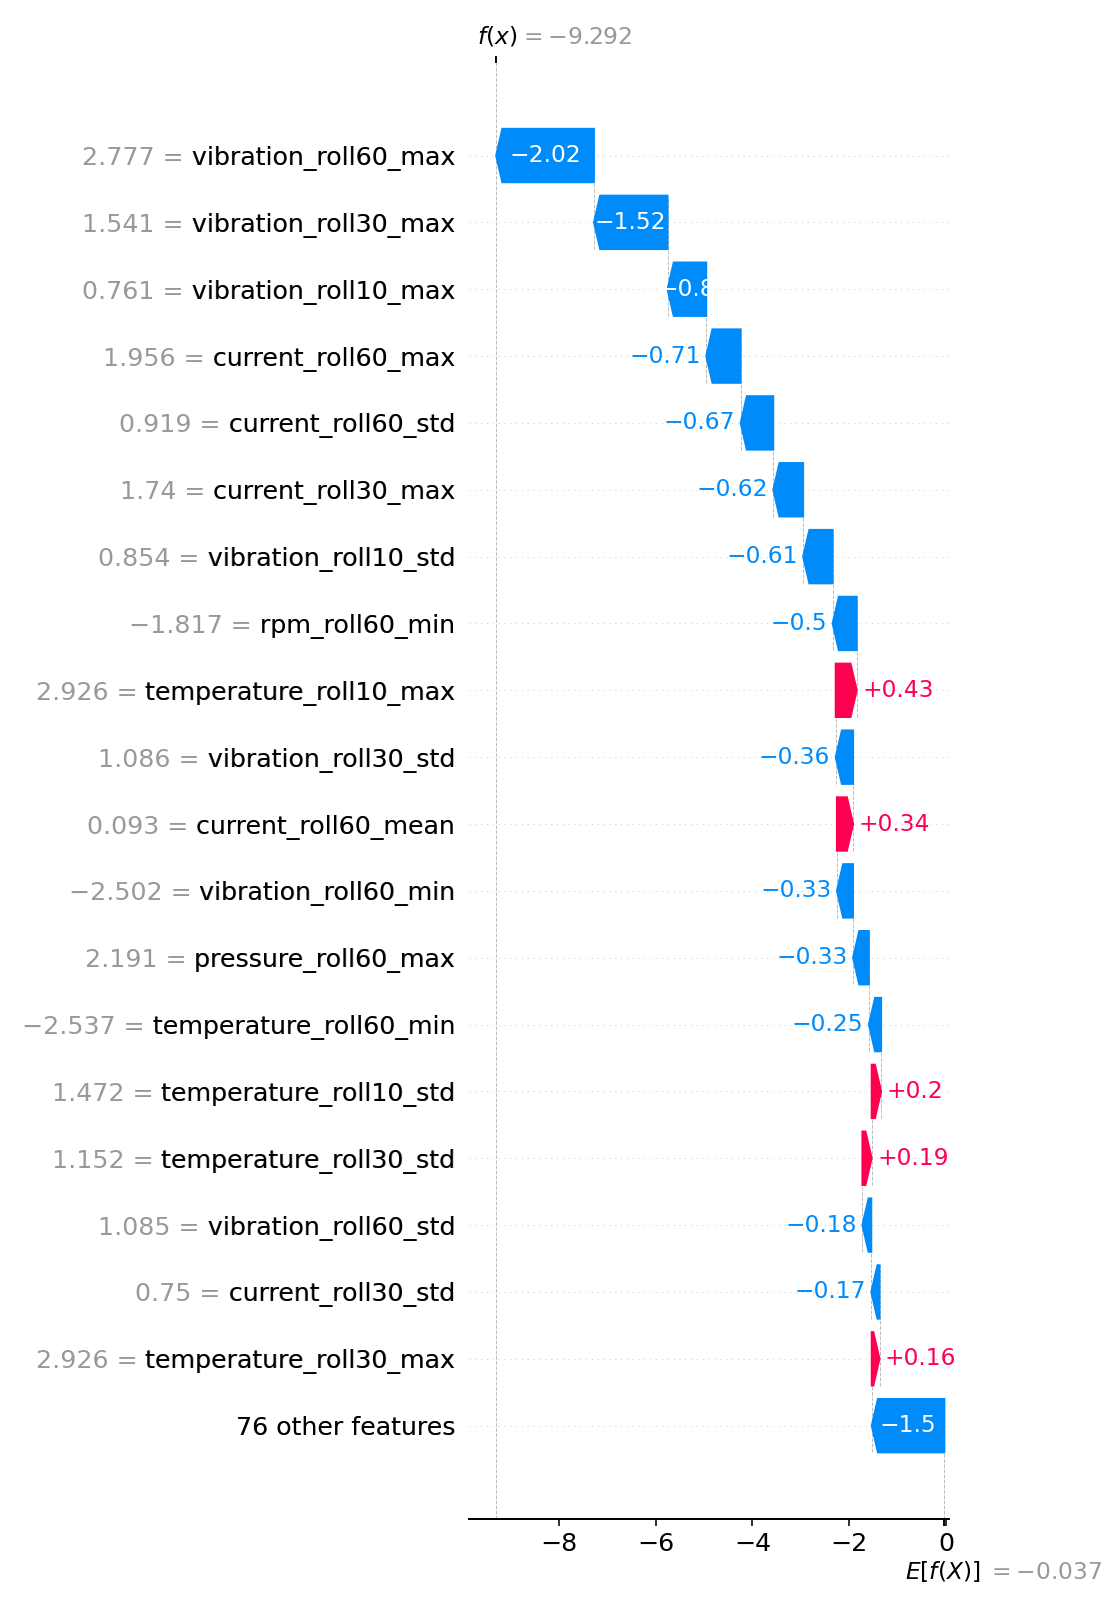

In [2]:
assets = Path("..").resolve() / "assets" / "images"
display(Image(filename=str(assets / "shap_summary_xgboost.png")))
display(Image(filename=str(assets / "shap_bar_xgboost.png")))
display(Image(filename=str(assets / "shap_waterfall_xgboost_row0.png")))

## Top 10 features by mean absolute SHAP value
We summarize the globally most influential predictors in a formatted table.

In [3]:
mean_abs = np.abs(shap_values).mean(axis=0)
top_idx = np.argsort(mean_abs)[::-1][:10]
top_table = pd.DataFrame({
    "feature": [X_sample.columns[i] for i in top_idx],
    "mean_abs_shap": [mean_abs[i] for i in top_idx],
})
display(top_table.style.format({"mean_abs_shap": "{:.6f}"}))

,feature,mean_abs_shap
0,vibration_roll60_max,1.953781
1,vibration_roll30_max,1.303954
2,current_roll60_std,0.674906
3,temperature_roll60_max,0.669615
4,vibration_roll30_std,0.521176
5,temperature_roll30_max,0.455880
6,vibration_roll10_max,0.444009
7,current_roll60_mean,0.425097
8,current_roll60_max,0.358949
9,vibration_roll60_std,0.329895


## Operational interpretation
SHAP indicates that vibration and current features dominate risk predictions. Operationally, this supports a condition-based maintenance strategy focused on vibration peaks and electrical load instability as early warning indicators.

In [4]:
print("Generated files:")
print(" -", summary_path)
print(" -", bar_path)
print(" -", waterfall_path)

Generated files:
 - C:\Users\avarg\OneDrive\Documentos\proyect-PMA\predictive-maintenance-automotive\reports\figures\shap_summary_xgboost.png
 - C:\Users\avarg\OneDrive\Documentos\proyect-PMA\predictive-maintenance-automotive\reports\figures\shap_bar_xgboost.png
 - C:\Users\avarg\OneDrive\Documentos\proyect-PMA\predictive-maintenance-automotive\reports\figures\shap_waterfall_xgboost_row0.png


Short conclusion: the model's decision logic aligns with plausible physical degradation behavior, which increases confidence for maintenance deployment.

In [5]:
top_table

,feature,mean_abs_shap
0,vibration_roll60_max,1.953781
1,vibration_roll30_max,1.303954
2,current_roll60_std,0.674906
3,temperature_roll60_max,0.669615
4,vibration_roll30_std,0.521176
5,temperature_roll30_max,0.455880
6,vibration_roll10_max,0.444009
7,current_roll60_mean,0.425097
8,current_roll60_max,0.358949
9,vibration_roll60_std,0.329895


The explainability workflow is complete and reproducible via both notebook and script (`python -m src.evaluation.shap_xgboost`).

In [6]:
print("Top SHAP driver:", top_table.iloc[0, 0])
print("Mean |SHAP|:", round(float(top_table.iloc[0, 1]), 6))

Top SHAP driver: vibration_roll60_max
Mean |SHAP|: 1.953781


End of Notebook 7.